# Marches spatiales Lune/Mars — analyse statistique

Ce notebook rassemble et **explique** les résultats produits par le pipeline
`analysis/run_analysis.py` sur les deux sources de données de l'expérience
« Interaction study in simulated space » (marches spatiales) :

1. **Les enregistrements inertiels (IMU)** du siège simulateur de gravité,
   dans `data/moon_mars_walk_data/` (un fichier CSV par session de marche).
2. **Les questionnaires** dans `data/EuroSpaceCenter-Questionnaires.xlsx`
   (échelle émotionnelle/somatique à 26 items, et Presence Questionnaire à
   32 items, Witmer & Singer 1998).

### Trois limites méthodologiques à garder en tête pendant toute la lecture

- **Lune et Mars sont regroupées.** Rien dans les fichiers IMU n'indique la
  condition de gravité d'une session : cette information vit dans le journal
  de session de l'expérimentateur (cf. protocole), absent de ce dépôt. Toutes
  les statistiques IMU ci-dessous poolent donc les deux conditions.
- **IMU et questionnaires ne sont pas reliés.** Les noms de fichiers IMU sont
  de simples timestamps Unix, sans identifiant participant. Il n'est
  actuellement pas possible d'attribuer une session de marche à un
  répondant précis.
- **Le Presence Questionnaire mélange des items formulés positivement et
  négativement**, et ce notebook n'a pas de clé d'inversion confirmée pour
  ce dépôt. Les scores ci-dessous sont donc calculés sur les items **bruts**
  (non inversés) — voir la section Fiabilité pour un diagnostic qui identifie
  empiriquement les items suspects.


In [1]:
import sys, os

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir)) if os.path.basename(os.getcwd()) == "analysis" else os.getcwd()
ANALYSIS_DIR = os.path.join(REPO_ROOT, "analysis")
sys.path.insert(0, ANALYSIS_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import imu
import questionnaire as q
import run_analysis as ra  # reuses the exact plotting helpers used to produce output/figures

%matplotlib inline
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 60)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = os.path.join(REPO_ROOT, "data")
IMU_DIR = os.path.join(DATA_DIR, "moon_mars_walk_data")
QUESTIONNAIRE_PATH = os.path.join(DATA_DIR, "EuroSpaceCenter-Questionnaires.xlsx")

print("Repo root:", REPO_ROOT)


Repo root: /Users/madeleinevanderschelden/Documents/UNIVERSITE/MASTER GESTION/MEMOIRE/Memoire_Gustin_Vanderschelden


## 1. Enregistrements inertiels (IMU) du siège

Le protocole indique un smartphone fixé sur le siège, échantillonnant à
100 Hz : `gFx/gFy/gFz` (accélération avec gravité), `ax/ay/az` (accélération
linéaire sans gravité), `wx/wy/wz` (gyroscope), `yaw/pitch/roll`
(orientation). **Le téléphone est fixé au siège, pas au corps** : ces
signaux décrivent la réponse mécanique du siège, pas directement le
mouvement du participant.

### 1.1 Qualité des sessions

Le dossier contient 36 fichiers bruts. Chaque session est chargée puis
évaluée sur deux critères : présence de toutes les colonnes attendues, et
au moins 500 échantillons (~5 s à 100 Hz). Ce seuil n'est pas arbitraire —
il isole exactement les sessions que le protocole appelle "complete enough",
comme vérifié ci-dessous.


In [2]:
sessions, quality = imu.load_all_sessions(IMU_DIR)

n_total = len(quality)
n_usable = int(quality["usable"].sum())
print(f"Sessions trouvées : {n_total}")
print(f"Sessions utilisables (>= {imu.MIN_SAMPLES_FOR_USABLE} échantillons, toutes colonnes présentes) : {n_usable}")
print(f"Sessions exclues : {n_total - n_usable}")

quality.sort_values("n_samples").head(10)


Sessions trouvées : 36
Sessions utilisables (>= 500 échantillons, toutes colonnes présentes) : 32
Sessions exclues : 4


,n_samples,has_all_columns,median_dt_s,wallclock_duration_s,nominal_duration_s,n_gaps_gt_1s,total_gap_s,max_gap_s,usable
session_id,,,,,,,,,
multi_1728642680.567175,99,False,0.01,0.976,0.99,0,0.000,0.000,False
multi_1728642726.45055,111,False,0.01,1.099,1.11,0,0.000,0.000,False
multi_1728652786.1821132,216,True,0.01,2.148,2.16,0,0.000,0.000,False
multi_1728642743.331891,243,False,0.01,2.420,2.43,0,0.000,0.000,False
multi_1728651547.954052,3183,True,0.01,134.642,31.83,1,101.893,101.893,True
multi_1728650072.4056401,3197,True,0.01,152.558,31.97,1,119.629,119.629,True
multi_1728656335.2319689,3201,True,0.01,146.147,32.01,1,113.055,113.055,True
multi_1728648264.0338469,3206,True,0.01,115.908,32.06,1,82.840,82.840,True
multi_1728656537.97135,3214,True,0.01,127.042,32.14,1,93.975,93.975,True


Les 4 sessions exclues ci-dessous sont soit trop courtes (quelques secondes,
probablement des essais avortés), soit incomplètes (seul le gyroscope a été
enregistré, sans accéléromètre ni orientation). Le nombre restant, **32**,
correspond exactement au nombre de sessions IMU que le protocole rapporte
comme exploitables.


In [3]:
excluded = quality[~quality["usable"]]
excluded[["n_samples", "has_all_columns", "nominal_duration_s", "wallclock_duration_s"]]


,n_samples,has_all_columns,nominal_duration_s,wallclock_duration_s
session_id,,,,
multi_1728642680.567175,99,False,0.99,0.976
multi_1728642726.45055,111,False,1.11,1.099
multi_1728642743.331891,243,False,2.43,2.420
multi_1728652786.1821132,216,True,2.16,2.148


### 1.2 Statistiques robustes par session, puis entre sessions

Pour chaque session utilisable, on calcule des statistiques descriptives
**robustes** par canal (médiane, MAD, moyenne tronquée à 10 %, IQR, en plus
de la moyenne/écart-type classiques) — voir `stats_utils.describe_series`.

Ensuite, l'agrégation **entre sessions** traite chaque session (n = 32)
comme une observation, plutôt que de regrouper tous les échantillons bruts :
regrouper les échantillons bruts laisserait une session de 150 s peser deux
fois plus qu'une session de 75 s sans raison statistique valable, ce qui
n'est pas ce qu'on veut pour décrire "la marche moyenne". Un intervalle de
confiance bootstrap (BCa, 5000 réplications) accompagne chaque moyenne,
car n = 32 est trop petit pour se fier aveuglément à un IC gaussien.


In [4]:
session_stats = imu.per_session_channel_stats(sessions, quality, usable_only=True)
pooled = imu.aggregate_across_sessions(session_stats)

pooled.loc[["acc_mag", "gravity_mag", "gyro_mag"],
           ["n_sessions", "mean", "median", "sd", "mad", "mean_ci95_low", "mean_ci95_high"]]


,n_sessions,mean,median,sd,mad,mean_ci95_low,mean_ci95_high
channel,,,,,,,
acc_mag,32,1.056451,0.906050,0.699042,0.663647,0.848005,1.342216
gravity_mag,32,1.004545,1.002850,0.005192,0.003081,1.003149,1.006947
gyro_mag,32,0.134916,0.103259,0.084434,0.088171,0.108271,0.168287


**Lecture des trois lignes ci-dessus :**

- `gravity_mag` (norme du vecteur gravité `gFx,gFy,gFz`) est très proche de
  **1.0** avec une variabilité minuscule (SD ≈ 0.005) : c'est un test de
  cohérence qui **passe** — le capteur restitue bien ~1 g quel que soit
  l'axe, comme attendu pour la composante gravité seule.
- `acc_mag` (norme de l'accélération linéaire, sans gravité) a une moyenne
  ≈ 1.06 m/s² mais une médiane nettement plus basse (≈ 0.91) et une
  distribution asymétrique (à vérifier via le graphique ci-dessous) :
  le siège est globalement peu accéléré, avec des pics ponctuels.
- `gyro_mag` (vitesse angulaire) est faible en moyenne, cohérent avec un
  siège qui s'incline plutôt qu'il ne tourne rapidement.


In [5]:
ra._plot_imu(session_stats, quality)  # écrit aussi les PNG dans output/figures/
import glob
for f in sorted(glob.glob(os.path.join(REPO_ROOT, "output", "figures", "imu_*.png"))):
    print(f)


/Users/madeleinevanderschelden/Documents/UNIVERSITE/MASTER GESTION/MEMOIRE/Memoire_Gustin_Vanderschelden/output/figures/imu_channel_magnitude_boxplot.png
/Users/madeleinevanderschelden/Documents/UNIVERSITE/MASTER GESTION/MEMOIRE/Memoire_Gustin_Vanderschelden/output/figures/imu_session_duration_gaps.png


#### Écarts (gaps) d'enregistrement

Le graphique ci-dessous compare, pour chaque session utilisable, la durée
"horloge murale" (dernier timestamp − premier timestamp) à la durée
nominale (nombre d'échantillons / 100 Hz). Les points **au-dessus** de la
diagonale ont connu une ou plusieurs coupures d'enregistrement (téléphone
mis en arrière-plan, par exemple) : la durée réelle de marche est mieux
approximée par la durée nominale que par la durée horloge murale.


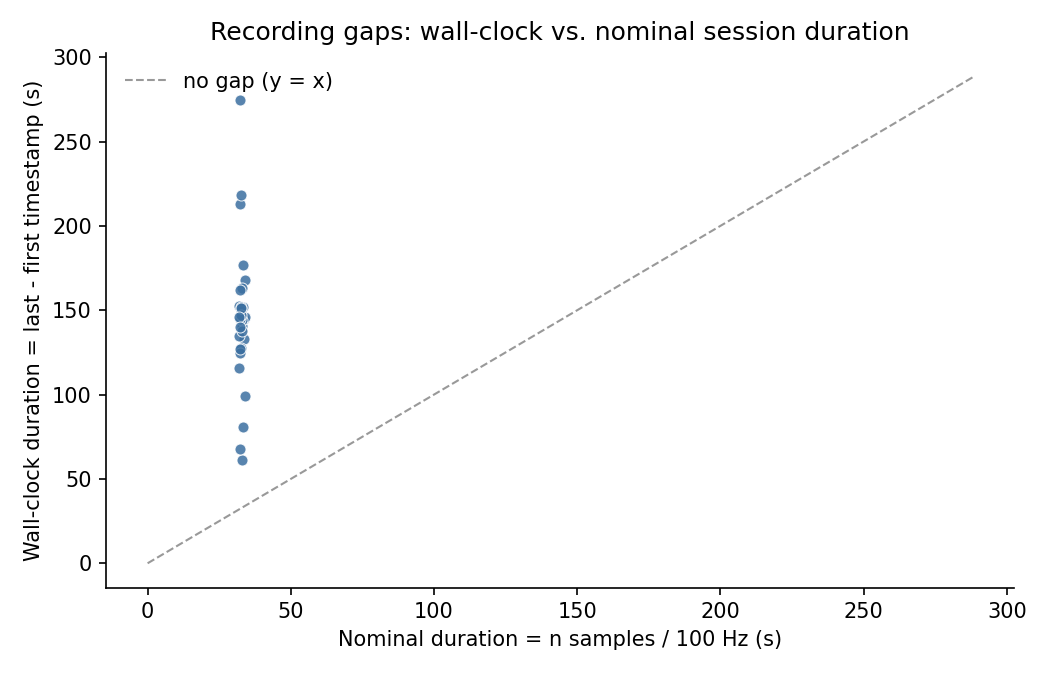

In [6]:
from IPython.display import Image, display
display(Image(filename=os.path.join(REPO_ROOT, "output", "figures", "imu_session_duration_gaps.png")))


#### Amplitude des signaux par canal

Boxplot des moyennes par session pour les trois normes de signal
(accélération linéaire, gravité, gyroscope). La boîte de `gravity_mag` est
quasi invisible : c'est attendu, la gravité est une constante (~1 g) que le
siège ne modifie pas. `acc_mag` a la dispersion la plus large entre
sessions, ce qui reflète des styles de marche / réponses de siège différents
selon les participants.


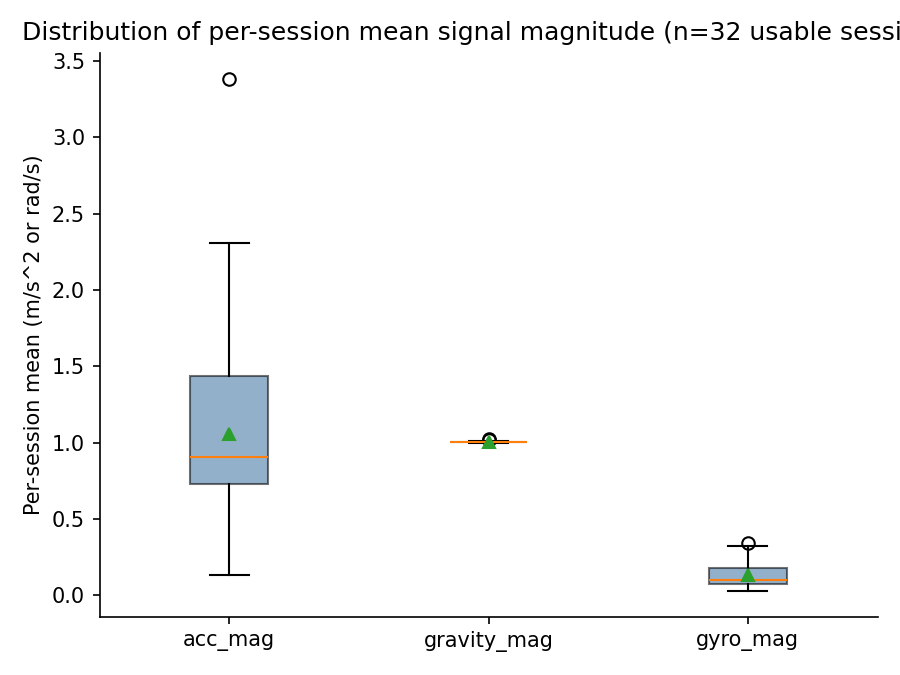

In [7]:
display(Image(filename=os.path.join(REPO_ROOT, "output", "figures", "imu_channel_magnitude_boxplot.png")))


### 1.3 Sessions aberrantes

Détection par z-score modifié médiane/MAD (Iglewicz & Hoaglin), sur la
moyenne de `acc_mag` par session — un critère robuste puisqu'il ne dépend
pas lui-même de la moyenne/écart-type classiques qu'on cherche à protéger
des valeurs extrêmes.


In [8]:
outliers = imu.flag_outlier_sessions(session_stats, channel="acc_mag", metric="mean")
n_out = int(outliers["is_outlier"].sum())
print(f"Sessions aberrantes détectées : {n_out} / {len(outliers)}")
outliers


Sessions aberrantes détectées : 0 / 32


,mean,is_outlier
session_id,,
multi_1728650072.4056401,0.130203,False
multi_1728649824.554737,0.143551,False
multi_1728653943.542037,0.159147,False
multi_1728649266.1441631,0.167782,False
multi_1728652544.508274,0.184561,False
multi_1728650309.359189,0.310558,False
multi_1728653344.048434,0.506822,False
multi_1728654410.9892302,0.676124,False
multi_1728656335.2319689,0.747789,False


### 1.4 Peut-on déduire la condition Lune/Mars à partir du signal du siège ?

Le siège n'est pas immobile pendant l'enregistrement : il est monté sur un
ressort qui le fait monter et descendre pour simuler la marche en gravité
réduite. Cette dynamique ne disparaît pas des données — mais il faut savoir
dans quel canal la chercher.

`gFx/gFy/gFz` et `ax/ay/az` ne sont pas deux capteurs physiques différents :
ce sont deux sorties calculées à partir du **même** accéléromètre, via le
filtrage standard (Android/iOS) qui sépare :
- la **gravité** (`gFx/gFy/gFz`) : une estimation lissée (passe-bas) de la
  direction et de l'intensité de la vraie gravité terrestre. Par
  construction, ce filtre **ignore** les mouvements rapides du téléphone et
  ne garde que la composante quasi constante — qui vaut ~9,81 m/s² partout
  sur Terre, ressort ou pas ;
- l'**accélération linéaire** (`ax/ay/az`) : tout le reste, c'est-à-dire
  précisément la dynamique rapide du siège (le ressort qui monte, qui
  descend, qui "décolle").

C'est pour ça que `gravity_mag` (1.2 ci-dessus, ≈ 1.0 avec SD ≈ 0.005 sur
les 32 sessions) ne peut structurellement pas encoder la condition simulée :
c'est une propriété du filtre logiciel, pas une limite du siège. En
revanche, si Lune et Mars sont simulées via un réglage différent du ressort
(raideur, amortissement, force d'assistance), cette différence de dynamique
devrait apparaître dans `acc_mag` (norme de `ax/ay/az`) et/ou `gyro_mag` —
les deux canaux qui captent effectivement le mouvement du siège.

On teste donc ci-dessous une hypothèse : un clustering non supervisé
(k-means, k=2) sur des features de session dérivées de `acc_mag`/`gyro_mag`
sépare-t-il les 32 sessions utilisables en deux groupes cohérents ?

**Limites à garder à l'esprit avant de lire les résultats :**
- Il n'existe **aucun label de vérité terrain** dans ce dépôt (le journal de
  session de l'expérimentateur, cf. protocole, n'y est pas) : ce clustering
  ne peut donc jamais être *validé*, seulement produire une hypothèse à
  confronter à ce journal quand il sera disponible.
- Même si les sessions se séparent proprement en deux groupes, rien ne
  garantit que cette séparation reflète la condition de gravité plutôt que,
  par exemple, des différences de style de marche ou de morphologie entre
  participants — ces deux sources de variabilité ne sont pas démêlées ici.
- Sans label, il est également impossible de savoir *quel* groupe correspond
  à la Lune et lequel à Mars (on pourrait supposer que Mars, gravité plus
  forte que la Lune, produit un signal plus marqué si le ressort est
  calibré sur la gravité réelle simulée — mais c'est une supposition, pas un
  résultat).

Ce qui suit est donc à lire comme une piste exploratoire pour la section
Limites, pas comme un ré-étiquetage fiable des sessions.


In [9]:
# Features par session : moyenne/médiane/écart-type/IQR de acc_mag et
# gyro_mag, les deux canaux qui captent la dynamique du siège (cf. 1.4).
FEATURE_CHANNELS = ["acc_mag", "gyro_mag"]
FEATURE_STATS = ["mean", "median", "sd", "iqr"]

feature_rows = []
for channel in FEATURE_CHANNELS:
    chan_stats = session_stats.xs(channel, level="channel")
    for stat in FEATURE_STATS:
        feature_rows.append(chan_stats[stat].rename(f"{channel}_{stat}"))
features = pd.concat(feature_rows, axis=1).dropna()
print(f"{features.shape[0]} sessions x {features.shape[1]} features")
features.round(3)


32 sessions x 8 features


,acc_mag_mean,acc_mag_median,acc_mag_sd,acc_mag_iqr,gyro_mag_mean,gyro_mag_median,gyro_mag_sd,gyro_mag_iqr
session_id,,,,,,,,
multi_1728648021.001131,1.437,1.363,0.894,1.234,0.275,0.208,0.263,0.235
multi_1728648264.0338469,1.171,0.929,1.095,1.599,0.151,0.123,0.129,0.194
multi_1728648542.4759622,0.912,0.830,0.588,0.832,0.235,0.157,0.255,0.212
multi_1728648795.166475,1.813,1.390,1.651,2.112,0.179,0.138,0.140,0.182
multi_1728649101.779892,0.861,0.657,0.739,1.094,0.217,0.124,0.256,0.243
multi_1728649266.1441631,0.168,0.149,0.115,0.119,0.031,0.024,0.030,0.023
multi_1728649548.4170341,1.453,1.255,1.092,1.158,0.182,0.149,0.137,0.134
multi_1728649824.554737,0.144,0.125,0.089,0.104,0.028,0.024,0.017,0.023
multi_1728650072.4056401,0.130,0.100,0.099,0.099,0.034,0.021,0.037,0.027


In [10]:
from scipy.cluster.vq import kmeans2, whiten

def stable_kmeans2(X, k=2, n_seeds=20, iters=50):
    """Run k-means from many random inits and keep the partition that recurs
    most often (up to label swap). With n=32 and no ground truth, a single
    run's result is not trustworthy on its own -- the agreement rate across
    seeds is itself the diagnostic of interest.
    """
    partitions = []
    for seed in range(n_seeds):
        _, labels = kmeans2(X, k, iter=iters, minit="++", seed=seed)
        partitions.append(tuple(labels))
    canonical = [p if p[0] == 0 else tuple(1 - np.array(p)) for p in partitions]
    counts = pd.Series(canonical).value_counts()
    best_partition = np.array(counts.index[0])
    agreement = counts.iloc[0] / n_seeds
    return best_partition, agreement

X = whiten(features.to_numpy())  # z-score chaque feature avant clustering
labels, agreement = stable_kmeans2(X, k=2, n_seeds=20)
features["cluster"] = labels

print(f"Partition la plus fréquente sur 20 initialisations aléatoires : {agreement:.0%} d'accord")
features["cluster"].value_counts().rename("n_sessions").to_frame()


Partition la plus fréquente sur 20 initialisations aléatoires : 90% d'accord


,n_sessions
cluster,
1,19
0,13


In [11]:
centroids = features.groupby("cluster")[[f"{c}_{s}" for c in FEATURE_CHANNELS for s in FEATURE_STATS]].mean()
centroids.T.round(3)


cluster,0,1
acc_mag_mean,1.636,0.660
acc_mag_median,1.240,0.273
acc_mag_sd,1.451,0.912
acc_mag_iqr,1.792,0.644
gyro_mag_mean,0.217,0.079
gyro_mag_median,0.160,0.052
gyro_mag_sd,0.198,0.077
gyro_mag_iqr,0.221,0.075


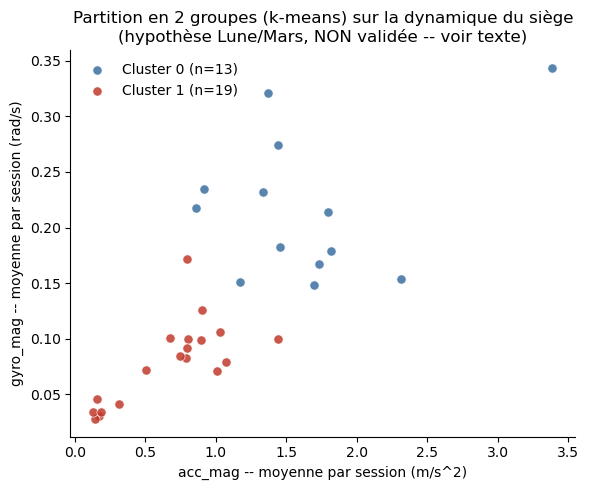

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = ["#3B6FA0", "#C0392B"]
for cluster_id, group in features.groupby("cluster"):
    ax.scatter(group["acc_mag_mean"], group["gyro_mag_mean"],
               color=colors[cluster_id], s=44, alpha=0.85,
               edgecolor="white", linewidth=0.5,
               label=f"Cluster {cluster_id} (n={len(group)})")
ax.set_xlabel("acc_mag -- moyenne par session (m/s^2)")
ax.set_ylabel("gyro_mag -- moyenne par session (rad/s)")
ax.set_title("Partition en 2 groupes (k-means) sur la dynamique du siège\n"
              "(hypothèse Lune/Mars, NON validée -- voir texte)")
ax.legend(frameon=False)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(REPO_ROOT, "output", "figures", "imu_gravity_condition_hypothesis_clusters.png"), dpi=150)
plt.show()


**Lecture des résultats :**

- La partition en 2 groupes est **stable** : sur 20 initialisations
  aléatoires du k-means, la même partition (13 sessions contre 19) revient
  dans 90 % des cas — ce n'est pas un artefact d'une seule initialisation
  chanceuse.
- La séparation n'est pas portée par une seule feature isolée : le groupe à
  13 sessions a une moyenne, une médiane, un écart-type **et** un IQR
  systématiquement plus élevés que l'autre groupe, à la fois sur `acc_mag`
  et sur `gyro_mag` (à peu près 2 à 3 fois plus élevés selon la statistique
  — voir le tableau de centroïdes ci-dessus). C'est cohérent avec l'idée que
  le ressort du siège se comporte réellement différemment entre les deux
  groupes de sessions, plutôt qu'avec du simple bruit de mesure.
- **Ce que ça ne dit pas** : lequel des deux groupes est la Lune et lequel
  est Mars, ni même si cette séparation reflète la condition de gravité
  plutôt qu'un autre facteur confondu avec elle (participant, jour
  d'enregistrement, réglage du siège modifié en cours d'expérience...).
  Sans le journal de session de l'expérimentateur, cette question reste
  ouverte.

**Comment l'utiliser :** dès que le journal de session sera disponible,
comparer directement l'assignation `cluster` de chaque session à la
condition réelle qu'il indique. Un fort recouvrement confirmerait que le
ressort encode bien la condition simulée dans `acc_mag`/`gyro_mag`, et
validerait cette méthode pour d'éventuelles collectes futures sans journal
séparé ; un recouvrement faible indiquerait que la séparation observée vient
d'autre chose (participant, style de marche...) et qu'il faudrait revenir au
regroupement Lune/Mars complet.


## 2. Questionnaires (section SPATIAL WALKING)

Le classeur Excel est structuré de façon transposée : une ligne par item,
une colonne par participant. Il contient, dans l'ordre, la section
**SPATIAL WALKING** (26 items émotionnels/somatiques puis 32 items du
Presence Questionnaire) et une section **ROTOR** qui appartient à une
expérience indépendante (cabine rotative), hors du périmètre de cette
thèse.

Le parseur (`questionnaire.parse_workbook`) ne suppose **aucun numéro de
ligne fixe** : il détecte les frontières de section et de bloc directement
depuis les libellés ("SPATIAL WALKING", "ROTOR", et la numérotation "1.",
"2." des items qui repart à 1 à chaque nouveau questionnaire). C'est plus
robuste qu'un découpage par numéro de ligne codé en dur, et ça permet de
vérifier la cohérence : on doit retrouver un bloc de 26 items et un bloc de
32 items dans SPATIAL WALKING.


In [13]:
emotional_df, presence_df = q.load_spatial_walking_questionnaires(QUESTIONNAIRE_PATH)

print(f"Échelle émotionnelle : {emotional_df.shape[1]} items, "
      f"{emotional_df.notna().any(axis=1).sum()} répondants (>=1 item répondu) "
      f"sur {emotional_df.shape[0]} identifiants")
print(f"Presence Questionnaire : {presence_df.shape[1]} items, "
      f"{presence_df.notna().any(axis=1).sum()} répondants (>=1 item répondu) "
      f"sur {presence_df.shape[0]} identifiants")


Échelle émotionnelle : 26 items, 44 répondants (>=1 item répondu) sur 46 identifiants
Presence Questionnaire : 32 items, 43 répondants (>=1 item répondu) sur 46 identifiants


Ces effectifs (44 et 43) correspondent exactement à ceux rapportés dans le
protocole pour les questionnaires des marches spatiales.

### 2.1 Statistiques par item

Moyenne, médiane, écart-type, MAD, IQR, min/max, asymétrie/aplatissement,
et complétude, pour chaque item — triées par moyenne décroissante.


In [14]:
emotional_items = q.item_stats_table(emotional_df)
emotional_items[["n_valid", "n_missing", "mean", "median", "sd", "iqr", "skewness"]]


,n_valid,n_missing,mean,median,sd,iqr,skewness
item,,,,,,,
1. Isolation and loneliness,44.0,2.0,1.636364,1.5,1.511059,3.00,0.390168
10. Feeling of isolation from people and things,44.0,2.0,1.272727,1.0,1.604697,2.00,1.016279
24. I felt isolated from everything and everyone,44.0,2.0,1.068182,0.5,1.404275,2.00,1.203256
3. Feeling my heart beating,44.0,2.0,0.863636,0.0,1.286620,1.25,1.449474
14. Anxiousness,43.0,3.0,0.651163,0.0,1.251356,1.00,2.085816
15. I felt shaky inside,44.0,2.0,0.522727,0.0,1.171138,0.25,2.580923
5. Feeling my body shake/tremble,44.0,2.0,0.522727,0.0,1.130726,0.00,2.286289
7. Experience of fear,44.0,2.0,0.431818,0.0,0.925045,1.00,3.143988
6. Feelings of grief,44.0,2.0,0.409091,0.0,1.187497,0.00,2.873883


L'échelle émotionnelle est fortement asymétrique à droite pour la plupart
des items (skewness positive) : la majorité des participants rapportent des
scores proches de 0 (« pas du tout »), avec une minorité de scores élevés.
« Isolation and loneliness » et les items liés à l'isolement dominent en
moyenne — cohérent avec l'expérience d'une marche solitaire sur une surface
planétaire déserte.


In [15]:
presence_items = q.item_stats_table(presence_df)
presence_items[["n_valid", "n_missing", "mean", "median", "sd", "iqr", "skewness"]]


,n_valid,n_missing,mean,median,sd,iqr,skewness
item,,,,,,,
5. How much did the visual aspects of the environment involve you?,42.0,4.0,5.690476,6.0,1.297053,2.00,-1.105334
26. How quickly did you adjust to the virtual environment experience?,40.0,6.0,5.575000,6.0,1.448031,2.00,-1.228723
27. How proficient in moving and interacting with the virtual environment did you feel at the end of the experience?,40.0,6.0,5.400000,6.0,1.373747,1.00,-1.050524
23. How involved were you in the virtual environment experience?,40.0,6.0,5.350000,6.0,1.561557,3.00,-0.924534
14. How completely were you able to actively survey or search the environment using vision?,42.0,4.0,5.071429,5.5,1.879191,2.75,-0.952457
30. How well could you concentrate on the assigned tasks or required activities rather than on the mechanisms used to perform those tasks or activities?,40.0,6.0,5.050000,5.0,1.484104,2.00,-0.420159
4. How completely were all of your senses engaged?,42.0,4.0,5.023810,5.0,1.522003,2.00,-0.250552
18. How compelling was your sense of moving around inside the virtual environment?,40.0,6.0,4.775000,5.0,1.593054,2.00,-0.897534
2. How responsive was the environment to actions that you initiated (or performed)?,42.0,4.0,4.761905,5.0,1.445085,2.00,-0.313114


### 2.2 Fiabilité des échelles (alpha de Cronbach) et items suspects

L'alpha est calculé sur les items **bruts** (sans inversion), en ne gardant
que les participants ayant répondu à tous les items du bloc (listwise). Le
nombre de participants réellement utilisé est indiqué à chaque fois — ce
n'est jamais une approximation silencieuse.


In [16]:
emotional_rel = q.reliability_report(emotional_df)
presence_rel = q.reliability_report(presence_df)

print(f"Alpha de Cronbach — échelle émotionnelle : "
      f"{emotional_rel['alpha']['alpha']:.3f} (n={emotional_rel['alpha']['n_participants']})")
print(f"Alpha de Cronbach — Presence Questionnaire (items bruts) : "
      f"{presence_rel['alpha']['alpha']:.3f} (n={presence_rel['alpha']['n_participants']})")


Alpha de Cronbach — échelle émotionnelle : 0.948 (n=43)
Alpha de Cronbach — Presence Questionnaire (items bruts) : 0.831 (n=39)


Les deux alphas sont élevés (> 0.80), ce qui est attendu même sans inversion
des items négatifs : la plupart des items d'un même questionnaire restent
corrélés entre eux. La corrélation item-total **corrigée** (chaque item
contre la somme des autres) est un diagnostic plus fin : un item dont la
formulation est inversée par rapport au reste de l'échelle ressort avec une
corrélation faible, nulle ou négative.


In [17]:
weak_presence_items = presence_rel["item_total_correlations"][presence_rel["item_total_correlations"] < 0.2]
weak_presence_items.sort_values().to_frame("item_total_r")


,item_total_r
11. How inconsistent or disconnected was the information coming from your various senses?,-0.305411
22. To what degree did you feel confused or disoriented at the beginning of breaks or at the end of the experimental session?,-0.191912
24. How distracting was the control mechanism?,-0.159831
28. How much did the visual display quality interfere or distract you from performing assigned tasks or required activities?,-0.038125
29. How much did the control devices interfere with the performance of assigned tasks or with other activities?,-0.024238
25. How much delay did you experience between your actions and expected outcomes?,-0.011044


**C'est exactement ce qu'on observe** : les items ressortis ci-dessus
(« How inconsistent or disconnected... », « How distracting was the control
mechanism... », « How much delay... », etc.) sont, dans leur formulation,
les items négatifs du Presence Questionnaire (ils mesurent une gêne/un
défaut, alors que la majorité des items mesurent un sentiment de présence
positif). Ce diagnostic ne remplace pas une clé d'inversion officielle
confirmée (Witmer & Singer 1998 ou la version utilisée dans le protocole),
mais il confirme, à partir des données elles-mêmes, quels items sont
probablement à inverser avant de calculer un score de présence définitif.


### 2.3 Scores d'échelle par participant et relation entre les deux questionnaires

Le score par participant est la **moyenne** des items répondus (et non la
somme), pour rester sur l'échelle d'origine quel que soit le nombre d'items
manquants ; `n_items_used` est conservé pour chaque participant.


In [18]:
emotional_scores = q.scale_scores(emotional_df)
presence_scores = q.scale_scores(presence_df)

corr = q.scale_correlation(emotional_scores["score_mean"], presence_scores["score_mean"])
print(f"n participants avec les deux scores : {corr['n']}")
print(f"Pearson  r = {corr['pearson_r']:.3f}  (IC 95% [{corr['pearson_ci95_low']:.3f}, {corr['pearson_ci95_high']:.3f}]),  p = {corr['pearson_p']:.4f}")
print(f"Spearman r = {corr['spearman_r']:.3f},  p = {corr['spearman_p']:.4f}")


n participants avec les deux scores : 43
Pearson  r = -0.127  (IC 95% [-0.437, 0.300]),  p = 0.4168
Spearman r = -0.124,  p = 0.4282


La corrélation entre le score émotionnel/somatique et le score de présence
est proche de zéro et non significative (p > 0.4) : dans cet échantillon,
le niveau de détresse émotionnelle/somatique rapporté n'est pas lié
linéairement au sentiment de présence rapporté. À noter, en gardant les
limites en tête : le score de présence n'est pas encore inversé sur ses
items négatifs (2.2), ce qui peut atténuer une relation réelle.


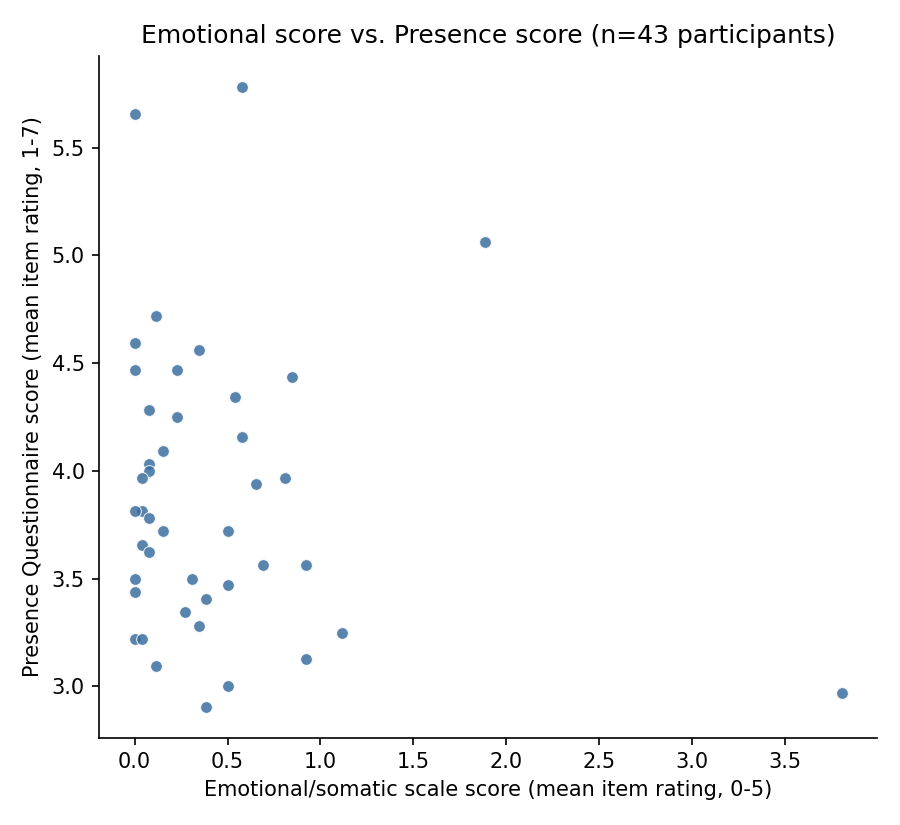

In [19]:
display(Image(filename=os.path.join(REPO_ROOT, "output", "figures", "questionnaire_emotional_vs_presence_scatter.png")))


### 2.4 Visualisation des items et de leurs corrélations


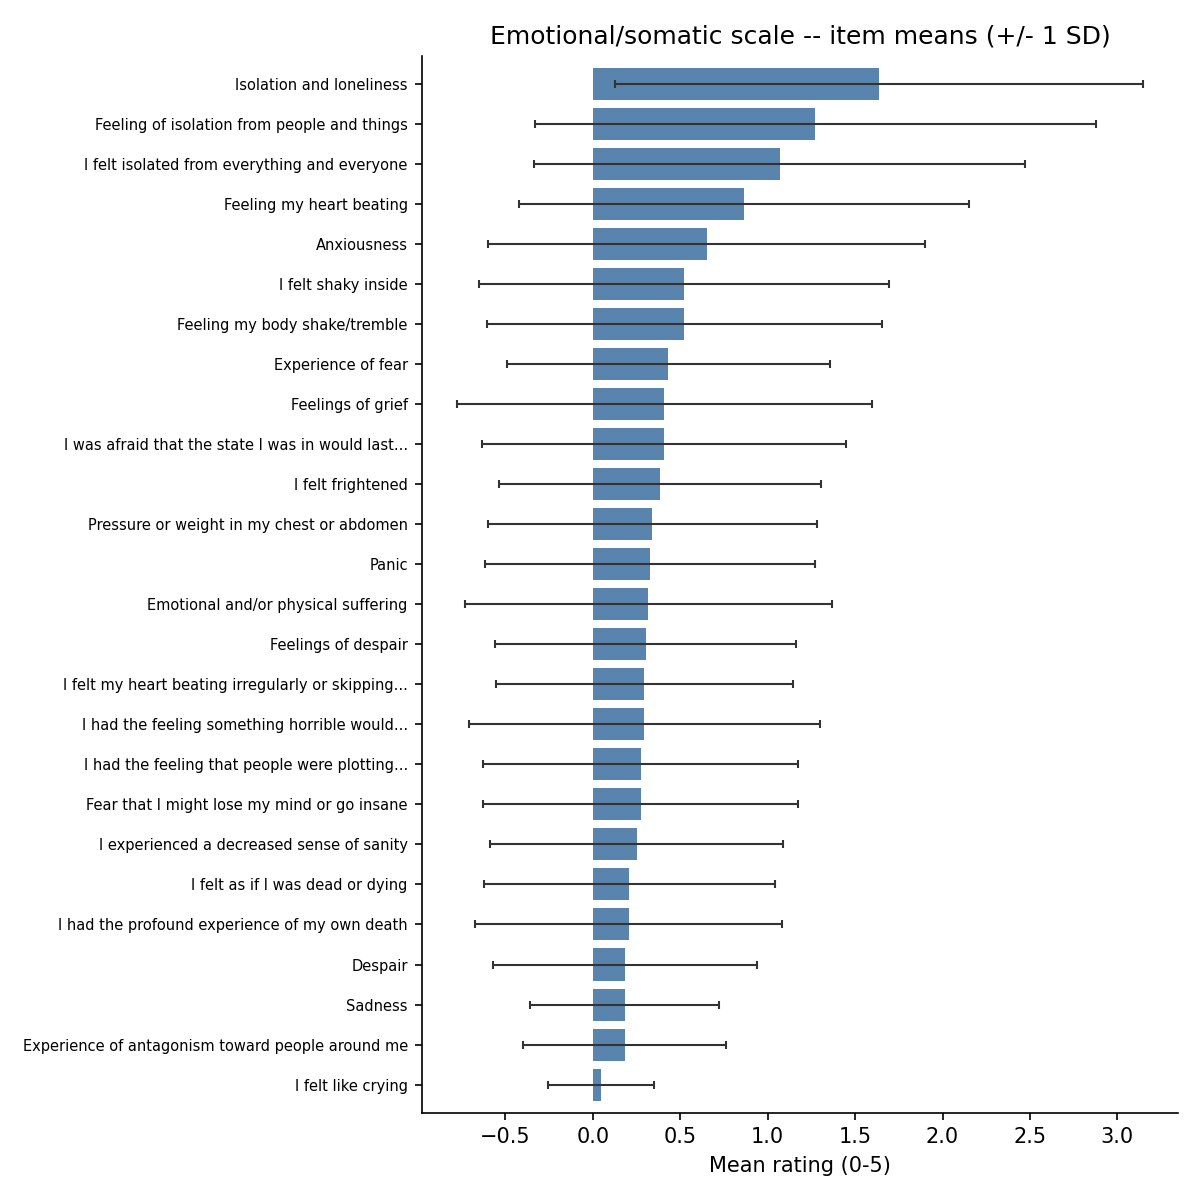

In [20]:
display(Image(filename=os.path.join(REPO_ROOT, "output", "figures", "questionnaire_emotional_item_means.png")))


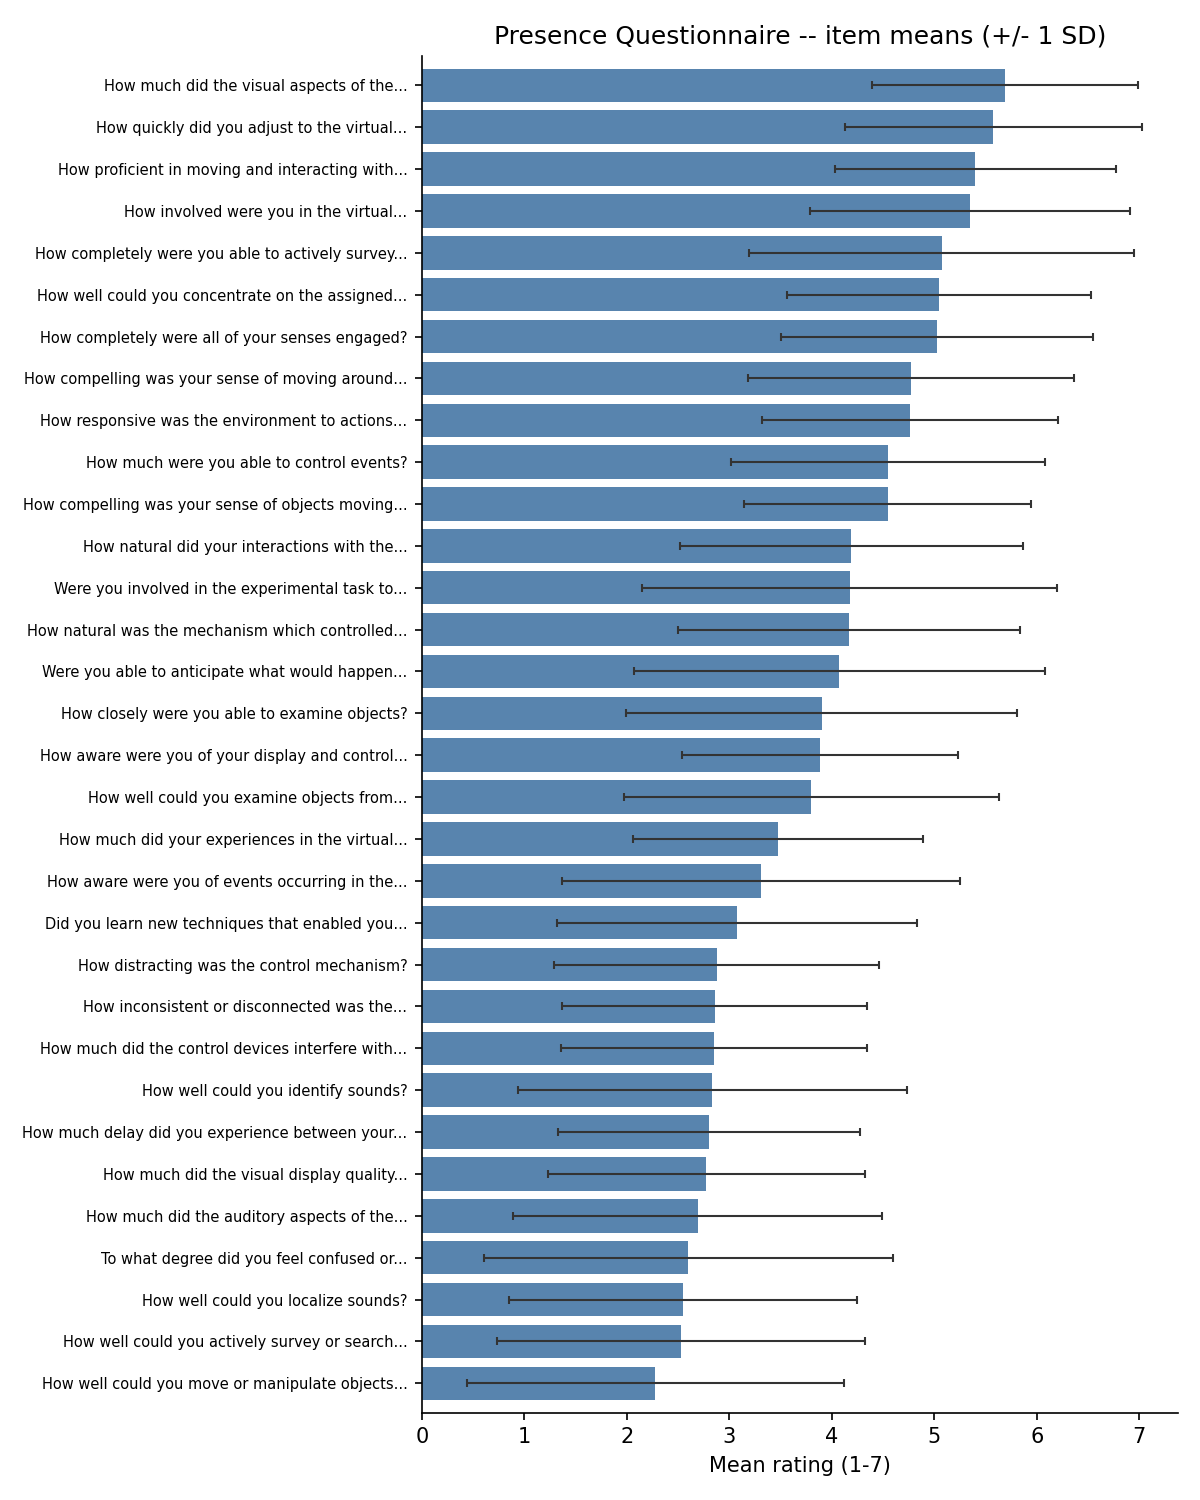

In [21]:
display(Image(filename=os.path.join(REPO_ROOT, "output", "figures", "questionnaire_presence_item_means.png")))


La carte de corrélation ci-dessous (Spearman, adapté à des réponses de type
Likert) montre des blocs de corrélations positives fortes le long de la
diagonale — des grappes d'items qui varient ensemble (probablement des
sous-dimensions du Presence Questionnaire : implication, fidélité
sensorielle, qualité d'interface...) — et des corrélations négatives
diffuses avec les quelques items formulés négativement identifiés en 2.2.


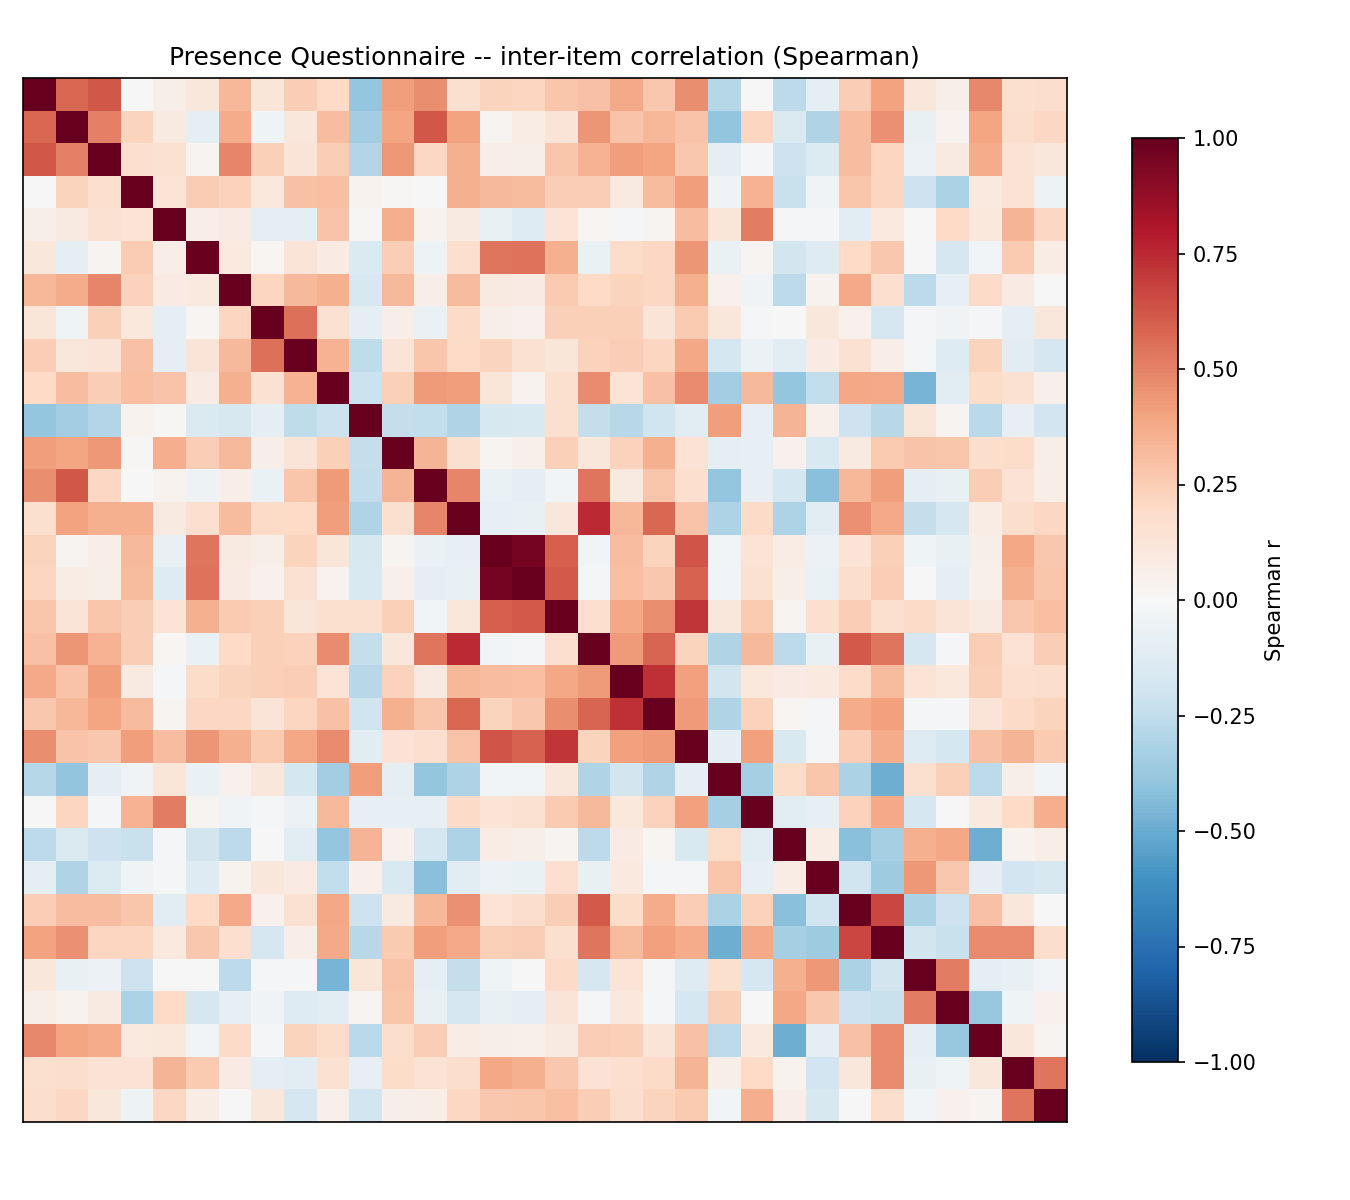

In [22]:
display(Image(filename=os.path.join(REPO_ROOT, "output", "figures", "questionnaire_presence_correlation_heatmap.png")))


## 3. Limites et prochaines étapes

- **Regroupement Lune/Mars** : à lever dès que le journal de session de
  l'expérimentateur (qui condition va avec quelle session, cf. protocole)
  est disponible — il suffira alors de scinder `session_stats` par
  condition avant l'agrégation de la section 1.2. La section 1.4 montre
  qu'un clustering exploratoire sur `acc_mag`/`gyro_mag` sépare les 32
  sessions en deux groupes stables et nettement distincts, cohérent avec
  deux réglages de ressort différents — mais **sans le journal, impossible
  de savoir quel groupe est quelle condition**, ni de confirmer que la
  séparation vient bien de la gravité simulée plutôt que d'un facteur
  confondu (participant, session...). À utiliser comme piste de validation
  croisée une fois le journal disponible, pas comme un ré-étiquetage.
- **Lien IMU ↔ questionnaire** : impossible avec les données actuelles (pas
  d'identifiant participant dans les noms de fichiers IMU). Dès qu'un
  mapping timestamp → identifiant existe, une jointure directe sur
  `emotional_scores` / `presence_scores` devient possible.
- **Inversion du Presence Questionnaire** : le diagnostic empirique de 2.2
  donne une liste de candidats plausibles, mais une clé de correction
  confirmée (source publiée ou version exacte utilisée dans le protocole)
  devrait être appliquée dans `questionnaire.py`
  (`REVERSE_SCORED_PRESENCE_ITEMS`) avant de considérer le score de présence
  comme définitif pour la thèse.

Tous les tableaux complets (pas seulement les extraits affichés ici) sont
disponibles en CSV dans `output/`, et toutes les figures en PNG dans
`output/figures/`.
